# Máquinas Térmicas - Lección 4
## Combustibles Fósiles: geología, carbón, petróleo y gas

**Autor:** Camilo Bayona
**Fecha:** 23/07/2025

*Continuación de la Lección 3 (Ciclos Biogeoquímicos): el destino litosférico del carbono capturado por la fotosíntesis.*


### Objetivos de aprendizaje
1. Explicar cómo el **ciclo del carbono** (Lección 3) origina el carbón, el petróleo y el gas natural.
2. Describir la **carbonificación** (turba → antracita) y relacionar rango, contenido de carbono y poder calorífico.
3. Introducir la **geología del petróleo**: roca generadora, ventana de generación, migración y trampas.
4. Cuantificar el **poder calorífico** de los combustibles fósiles y su lugar en la matriz energética.

## 1. Introducción
Los combustibles fósiles son carbono orgánico que la fotosíntesis retiró de la atmósfera y que quedó **enterrado en la litosfera** durante millones de años (véase el ciclo del carbono en la Lección 3). Bajo presión y temperatura crecientes, esa materia orgánica se transforma en carbón (de origen vegetal continental) o en hidrocarburos líquidos y gaseosos (de origen marino). Su combustión devuelve ese carbono a la atmósfera en una escala de tiempo de **siglos**, no de millones de años.


In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "networkx", "matplotlib", "pandas"], check=True)


In [2]:
# === Setup ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import networkx as nx
import pandas as pd
from ipywidgets import interact, FloatSlider, Dropdown

# Rangos del carbón: (nombre, C% típico, poder calorífico MJ/kg, H/C atómico, O/C atómico)
CARBON = pd.DataFrame({
    "rango":   ["Turba", "Lignito", "Sub-bituminoso", "Bituminoso", "Antracita"],
    "C_pct":   [55, 68, 76, 84, 93],
    "PCS_MJkg":[11, 18, 24, 31, 34],
    "HC":      [1.4, 1.0, 0.85, 0.75, 0.35],
    "OC":      [0.55, 0.30, 0.20, 0.10, 0.02],
})
print("Setup OK — rangos de carbón cargados:", ", ".join(CARBON["rango"]))


Setup OK — rangos de carbón cargados: Turba, Lignito, Sub-bituminoso, Bituminoso, Antracita


## 2. Origen de los combustibles fósiles
La secuencia general —común al carbón, el petróleo y el gas— va de los restos orgánicos a los yacimientos explotables:


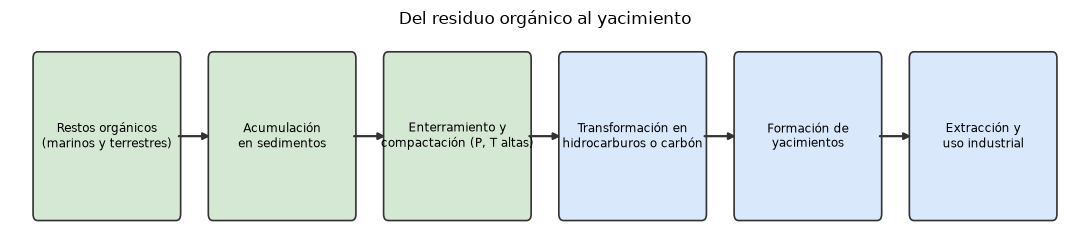

In [3]:
# Diagrama de flujo del origen de los combustibles fósiles (matplotlib, sin graphviz)
etapas = ["Restos orgánicos\n(marinos y terrestres)", "Acumulación\nen sedimentos",
          "Enterramiento y\ncompactación (P, T altas)", "Transformación en\nhidrocarburos o carbón",
          "Formación de\nyacimientos", "Extracción y\nuso industrial"]
fig, ax = plt.subplots(figsize=(11, 2.6))
n = len(etapas)
for i, txt in enumerate(etapas):
    x = i * 1.9
    ax.add_patch(patches.FancyBboxPatch((x, 0), 1.5, 1.2, boxstyle="round,pad=0.05",
                 facecolor="#D5E8D4" if i < 3 else "#DAE8FC", edgecolor="#333", lw=1.2))
    ax.text(x + 0.75, 0.6, txt, ha="center", va="center", fontsize=8.5)
    if i < n - 1:
        ax.annotate("", xy=(x + 1.9, 0.6), xytext=(x + 1.5, 0.6),
                    arrowprops=dict(arrowstyle="-|>", lw=1.6, color="#333"))
ax.set_xlim(-0.3, (n - 1) * 1.9 + 1.8); ax.set_ylim(-0.2, 1.4)
ax.axis("off"); ax.set_title("Del residuo orgánico al yacimiento", fontsize=12)
plt.tight_layout(); plt.show()


## Formación geológica del carbón

El carbón se formó a partir de restos de vegetación que crecieron hace cientos de millones de años. Durante el **período Carbonífero** (hace 350–280 Ma) y el **Pérmico** (280–225 Ma) grandes bosques de helechos y árboles depositaron capas de materia vegetal en zonas pantanosas. Estos restos quedaron enterrados bajo sedimentos y fueron transformados por hongos y bacterias en condiciones **anaeróbicas**. El proceso de **carbonificación** implica la compactación, eliminación de humedad y aumento del contenido de carbono, bajo temperaturas moderadas (~250 °C) y altas presiones. A medida que aumentan la profundidad y el tiempo de enterramiento, la materia vegetal se convierte progresivamente en turba, lignito, hulla y antracita, con incrementos en el poder calorífico.

La calidad del carbón se evalúa por su porcentaje de **carbono fijo**, materia volátil, humedad y azufre; cuanto mayor es el contenido de carbono y la antigüedad, mayor es su rango y capacidad calorífica.

El carbón se clasifica en diferentes tipos según su contenido de carbono: turba, lignito, sub-bituminoso, bituminoso y antracita.

a. Turba:

![Peat](https://upload.wikimedia.org/wikipedia/commons/7/7d/Peat_%2849302157252%29.jpg)

b. Lignito

![Lignite](https://upload.wikimedia.org/wikipedia/commons/8/85/Pliocene_Lignite_Coal_Serbia.jpg)

c. Sub-bituminoso

![Bituminous](https://upload.wikimedia.org/wikipedia/commons/2/20/Coal_bituminous.jpg)

d. Bituminoso:

![Bituminous](https://upload.wikimedia.org/wikipedia/commons/2/2e/Handvoll_Gold.jpg)

e. Antracita:

![Anthracite](https://upload.wikimedia.org/wikipedia/commons/5/59/Anthracite_Coal_01_10x_%2838960276634%29.jpg)

> Las fotografías anteriores provienen de Wikimedia Commons (pueden no cargar sin conexión). El diagrama siguiente, **generado por código**, sintetiza la misma progresión de rango de forma reproducible.


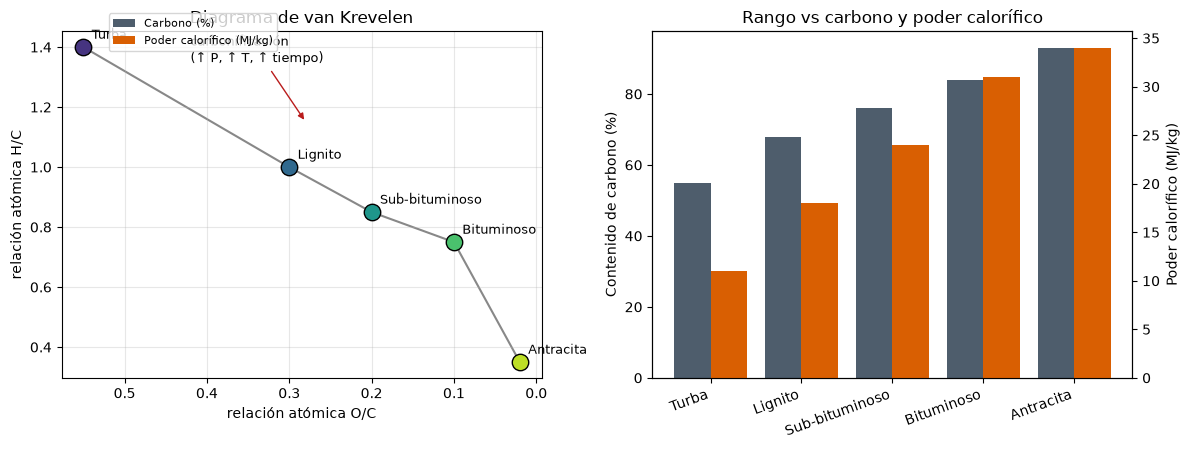

In [4]:
# Diagrama de van Krevelen: la carbonificación como pérdida de H y O respecto al C
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
colores = plt.cm.viridis(np.linspace(0.15, 0.9, len(CARBON)))
ax1.plot(CARBON["OC"], CARBON["HC"], "-", color="#888", zorder=1)
for i, r in CARBON.iterrows():
    ax1.scatter(r["OC"], r["HC"], s=140, color=colores[i], edgecolors="k", zorder=3)
    ax1.annotate(r["rango"], (r["OC"], r["HC"]), textcoords="offset points",
                 xytext=(6, 6), fontsize=9)
ax1.annotate("carbonificación\n(↑ P, ↑ T, ↑ tiempo)", (0.28, 1.15), (0.42, 1.35),
             fontsize=9, arrowprops=dict(arrowstyle="-|>", color="#B91C1C"))
ax1.set_xlabel("relación atómica O/C"); ax1.set_ylabel("relación atómica H/C")
ax1.set_title("Diagrama de van Krevelen"); ax1.grid(alpha=0.3); ax1.invert_xaxis()
x = np.arange(len(CARBON))
ax2.bar(x - 0.2, CARBON["C_pct"], width=0.4, color="#4e5d6c", label="Carbono (%)")
ax2b = ax2.twinx()
ax2b.bar(x + 0.2, CARBON["PCS_MJkg"], width=0.4, color="#d95f02", label="Poder calorífico (MJ/kg)")
ax2.set_xticks(x); ax2.set_xticklabels(CARBON["rango"], rotation=20, ha="right")
ax2.set_ylabel("Contenido de carbono (%)"); ax2b.set_ylabel("Poder calorífico (MJ/kg)")
ax2.set_title("Rango vs carbono y poder calorífico")
fig.legend(loc="upper left", bbox_to_anchor=(0.09, 0.97), fontsize=8)
plt.tight_layout(); plt.show()


![Peat](https://upload.wikimedia.org/wikipedia/commons/a/a1/Formation_periods_of_the_most_important_coal_deposits_worldwide.svg)

### 2.1 Periodos geológicos de mayor formación de carbón
El carbón proviene sobre todo del **Carbonífero** y el **Pérmico**, cuando extensos bosques pantanosos enterraron enormes cantidades de materia vegetal:


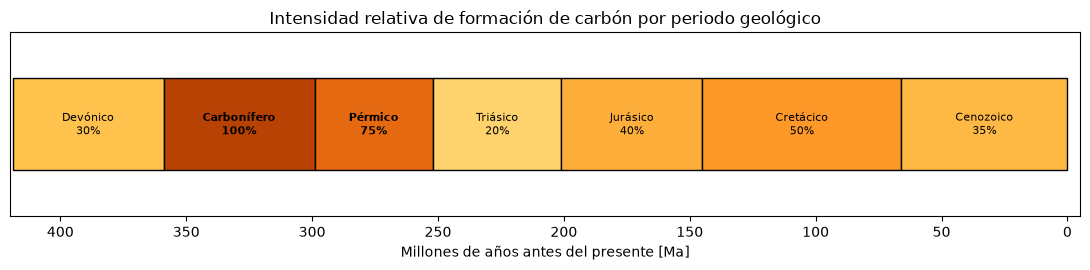

In [5]:
# Línea de tiempo geológica de la formación de carbón (generada por código)
periodos = [("Devónico", 419, 359, 0.3), ("Carbonífero", 359, 299, 1.0),
            ("Pérmico", 299, 252, 0.75), ("Triásico", 252, 201, 0.2),
            ("Jurásico", 201, 145, 0.4), ("Cretácico", 145, 66, 0.5),
            ("Cenozoico", 66, 0, 0.35)]
fig, ax = plt.subplots(figsize=(11, 2.8))
for nombre, ini, fin, intensidad in periodos:
    ax.barh(0, ini - fin, left=fin, height=0.6,
            color=plt.cm.YlOrBr(0.2 + 0.6 * intensidad), edgecolor="k")
    ax.text((ini + fin) / 2, 0, f"{nombre}\n{intensidad*100:.0f}%", ha="center", va="center",
            fontsize=8, fontweight="bold" if intensidad > 0.7 else "normal")
ax.set_xlim(420, -5); ax.set_ylim(-0.6, 0.6)
ax.set_xlabel("Millones de años antes del presente [Ma]")
ax.set_yticks([]); ax.set_title("Intensidad relativa de formación de carbón por periodo geológico")
plt.tight_layout(); plt.show()


## 3. Carbonificación: contenido de carbono y poder calorífico
A medida que aumentan la profundidad, la temperatura y el tiempo de enterramiento, el carbón gana carbono fijo y poder calorífico y pierde humedad y volátiles. El widget permite recorrer la serie:


In [4]:
# WIDGET — propiedades del carbón a lo largo de la carbonificación
def carbonificacion(rango="Bituminoso"):
    r = CARBON.set_index("rango").loc[rango]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.3, 1]})
    x = np.arange(len(CARBON)); sel = list(CARBON["rango"]).index(rango)
    ax1.plot(x, CARBON["C_pct"], "-o", color="#4e5d6c", label="Carbono (%)")
    ax1.plot(x, CARBON["PCS_MJkg"], "-o", color="#d95f02", label="Poder calorífico (MJ/kg)")
    ax1.axvline(sel, ls="--", color="#B91C1C")
    ax1.set_xticks(x); ax1.set_xticklabels(CARBON["rango"], rotation=20, ha="right")
    ax1.legend(); ax1.grid(alpha=0.3); ax1.set_title("Progresión de rango")
    # panel derecho: ficha del rango seleccionado
    ax2.axis("off")
    ax2.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor="#FEF9E7", edgecolor="#999"))
    ficha = (f"$\\bf{{{rango}}}$\n\n"
             f"Carbono fijo: {r['C_pct']:.0f} %\n"
             f"Poder calorífico: {r['PCS_MJkg']:.0f} MJ/kg\n"
             f"H/C atómico: {r['HC']:.2f}\n"
             f"O/C atómico: {r['OC']:.2f}\n\n"
             f"1 kg libera ≈ {r['PCS_MJkg']:.0f} MJ\n"
             f"(≈ {r['PCS_MJkg']/3.6:.1f} kWh)")
    ax2.text(0.5, 0.5, ficha, ha="center", va="center", fontsize=11)
    plt.tight_layout(); plt.show()

interact(carbonificacion,
         rango=Dropdown(options=list(CARBON["rango"]), value="Bituminoso", description="rango"));


interactive(children=(Dropdown(description='rango', index=3, options=('Turba', 'Lignito', 'Sub-bituminoso', 'B…

## Formación del petróleo y del gas natural

El petróleo y el gas natural se formaron a partir de restos de **organismos marinos** (zooplancton y fitoplancton) que se depositaron en fondos oceánicos ricos en sedimentos. El material orgánico fue enterrado rápidamente por aluviones y sedimentos fluviales, evitando su descomposición completa. Con el tiempo, la acumulación de sedimentos generó altas presiones y temperaturas que transformaron la materia orgánica en mezclas de hidrocarburos líquidos y gaseosos. Estas mezclas se alojaron en espacios porosos de rocas sedimentarias, formando **trampas** de petróleo y gas selladas por capas impermeables.

Formación del petróleo y gas natural (resumen):
- Materia orgánica marina se acumula en cuencas sedimentarias.
- El enterramiento y la falta de oxígeno impiden la descomposición y favorecen la transformación en hidrocarburos.
- La presión y el calor convierten la materia en petróleo y gas natural.
- Los hidrocarburos migran y se acumulan en rocas porosas bajo trampas geológicas.

Petroleo:

![Peat](https://upload.wikimedia.org/wikipedia/commons/a/ad/Crude_Oil_20180405_153958.jpg)

Gas Natural:

![Peat](https://upload.wikimedia.org/wikipedia/commons/8/8a/Darvasa_gas_crater_panorama.jpg)


| Etapa           | Proceso                                                                           | Tiempo escalado |
| --------------- | --------------------------------------------------------------------------------- | --------------- |
| **Generación**  | Transformación de materia orgánica a querógeno y luego a petróleo/gas (pirólisis) | 10⁶–10⁷ años    |
| **Migración**   | Desplazamiento del fluido hacia rocas reservorio                                  | continua        |
| **Acumulación** | Atrapamiento en estructuras anticlinales, fallas, domos salinos                   | continua        |


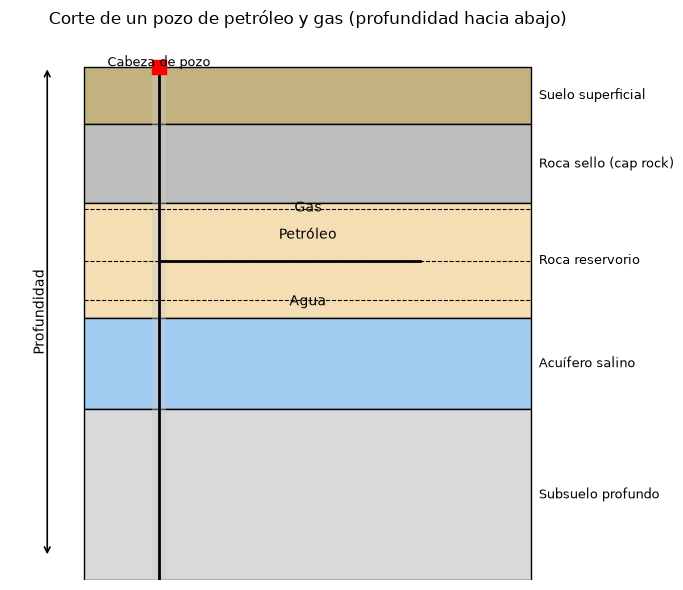

In [5]:
# Corte vertical de un pozo de petróleo y gas (profundidad hacia abajo)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 6))

# ------------------------------------------------------------------
# 1. Capas geológicas: (nombre, profundidad tope [km], espesor [km], color)
layers = [
    ("Suelo superficial",      0.00, 0.5, "#c2b280"),
    ("Roca sello (cap rock)",  0.50, 0.7, "#bdbdbd"),
    ("Roca reservorio",        1.20, 1.0, "#f5deb3"),
    ("Acuífero salino",        2.20, 0.8, "#a1caf1"),
    ("Subsuelo profundo",      3.00, 1.5, "#d9d9d9")
]

for name, top, thick, color in layers:
    rect = patches.Rectangle((0, top), 6, thick,
                             facecolor=color, edgecolor='k', lw=1)
    ax.add_patch(rect)
    ax.text(6.1, top + thick/2, name, va='center', fontsize=9)

# ------------------------------------------------------------------
# 2. Distribución de fluidos en la roca reservorio
top_res, thick_res = 1.20, 1.0
y_gas   = top_res + 0.05               # interfaz gas
y_oil   = top_res + 0.50               # interfaz petróleo-agua
y_water = top_res + 0.85               # base agua

ax.hlines([y_gas, y_oil, y_water], 0, 6, colors='k', ls='--', lw=0.8)
ax.text(3, y_gas   + 0.05, "Gas",       ha='center', va='bottom', fontsize=10)
ax.text(3, (y_gas + y_oil)/2, "Petróleo",ha='center', va='center', fontsize=10)
ax.text(3, y_water - 0.05, "Agua",      ha='center', va='top', fontsize=10)

# ------------------------------------------------------------------
# 3. Pozo vertical y rama horizontal
ax.add_line(Line2D([1, 1], [0, 4.5], color='black', lw=2))             # pozo vertical
ax.add_patch(patches.Rectangle((0.9, 0), 0.2, 4.5, facecolor='#cccccc', alpha=0.4))  # casing
ax.add_line(Line2D([1, 4.5], [y_oil, y_oil], color='black', lw=2))     # rama horizontal

# Cabeza de pozo
ax.plot(1, 0, marker='s', ms=10, color='red')
ax.text(1, -0.1, "Cabeza de pozo", ha='center', va='top', fontsize=9)

# ------------------------------------------------------------------
# 4. Flecha de profundidad (eje invertido)
ax.annotate("", xy=(-0.5, 4.3), xytext=(-0.5, 0),
            arrowprops=dict(arrowstyle="<->", lw=1.2))
ax.text(-0.6, 2.15, "Profundidad", rotation=90, ha='center', va='center')

# ------------------------------------------------------------------
# Ajustes finales
ax.set_xlim(-1, 7)
ax.set_ylim(4.5, -0.3)          # invertido: superficie arriba, profundidad abajo
ax.set_title("Corte de un pozo de petróleo y gas (profundidad hacia abajo)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


![Peat](https://upload.wikimedia.org/wikipedia/commons/c/ce/Uinta_Basin_geologic_cross_section.png)

### 4.1 La ventana de generación de hidrocarburos
La materia orgánica (querógeno) se transforma según la temperatura, que aumenta con la profundidad (gradiente geotérmico ≈ 25–30 °C/km):
- **< 60 °C:** diagénesis (aún querógeno inmaduro).
- **60–120 °C — ventana de petróleo:** craqueo térmico que genera petróleo líquido.
- **120–200 °C — ventana de gas:** el petróleo se craquea a gas.
- **> 200 °C:** solo gas seco / grafito.


In [6]:
# WIDGET — ventana de petróleo y gas según gradiente geotérmico
def ventana_hidrocarburos(grad_geot=28.0, T_superficie=15.0):
    prof = np.linspace(0, 6, 200)                 # km
    T = T_superficie + grad_geot * prof
    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.axhspan(0, 6, xmin=0, xmax=1, color="none")
    # bandas por temperatura -> profundidad
    def z(Tobj): return (Tobj - T_superficie) / grad_geot
    bandas = [(0, z(60), "#EAECEE", "Diagénesis\n(querógeno inmaduro)"),
              (z(60), z(120), "#7DCEA0", "Ventana de PETRÓLEO\n(60–120 °C)"),
              (z(120), z(200), "#F5B041", "Ventana de GAS\n(120–200 °C)"),
              (z(200), 6, "#CD6155", "Gas seco / grafito\n(>200 °C)")]
    for z0, z1, col, lab in bandas:
        z0c, z1c = max(0, z0), min(6, z1)
        if z1c > z0c:
            ax.axhspan(z0c, z1c, color=col, alpha=0.75)
            ax.text(0.55, (z0c + z1c) / 2, lab, ha="center", va="center", fontsize=9)
    axT = ax.twiny()
    axT.plot(T, prof, color="#B91C1C", lw=2)
    axT.set_xlabel("Temperatura [°C]", color="#B91C1C")
    axT.tick_params(axis="x", colors="#B91C1C")
    axT.invert_yaxis()
    ax.set_ylim(6, 0); ax.set_xlim(0, 1); ax.set_xticks([])
    ax.set_ylabel("Profundidad [km]")
    ax.set_title(f"Ventana de hidrocarburos (gradiente {grad_geot:.0f} °C/km)")
    z_oil0, z_oil1 = z(60), z(120)
    print(f"Ventana de petróleo: {z_oil0:.2f}–{z_oil1:.2f} km de profundidad "
          f"(a {grad_geot:.0f} °C/km desde {T_superficie:.0f} °C en superficie).")
    plt.tight_layout(); plt.show()

interact(ventana_hidrocarburos,
         grad_geot=FloatSlider(28, min=15, max=45, step=1, description="°C/km"),
         T_superficie=FloatSlider(15, min=0, max=35, step=1, description="T sup [°C]"));


interactive(children=(FloatSlider(value=28.0, description='°C/km', max=45.0, min=15.0, step=1.0), FloatSlider(…

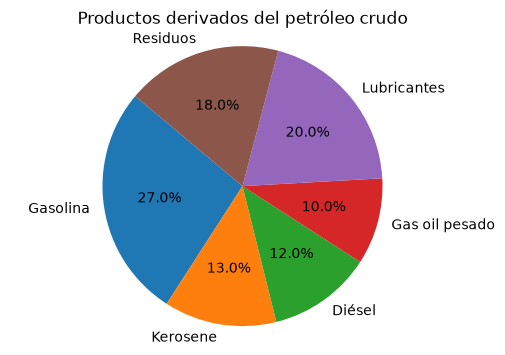

In [9]:

# Distribución aproximada de los productos derivados del petróleo crudo
import matplotlib.pyplot as plt

labels = ['Gasolina','Kerosene','Diésel','Gas oil pesado','Lubricantes','Residuos']
valores = [27,13,12,10,20,18]  # Porcentaje en volumen basado en una mezcla típica
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
plt.figure(figsize=(6,4))
plt.pie(valores, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.axis('equal')
plt.title('Productos derivados del petróleo crudo')
plt.show()


## 5. Refinación del petróleo
La **destilación fraccionada** separa el crudo por puntos de ebullición: las fracciones ligeras (gases, nafta) salen por la parte alta de la torre y las pesadas (fuel oil, residuo) por la base.


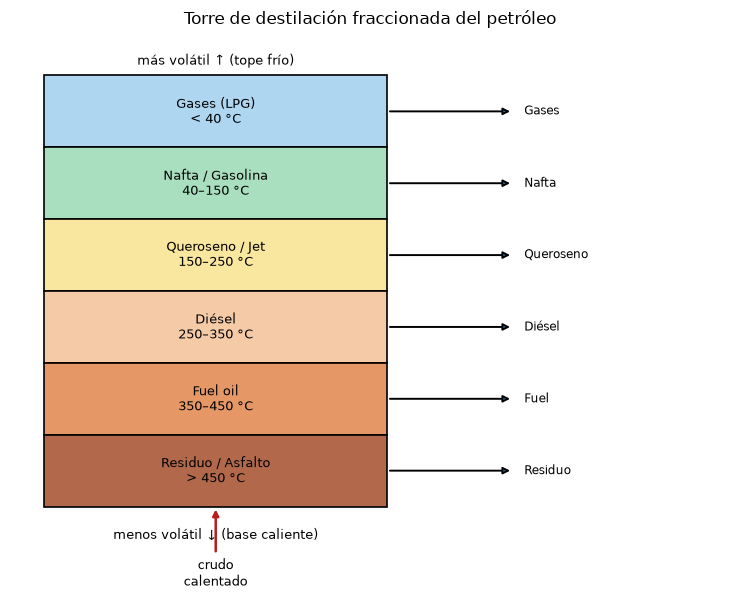

In [10]:
# Torre de destilación fraccionada (matplotlib, reemplaza el graphviz-dot original)
fracciones = [("Gases (LPG)", "< 40 °C", "#AED6F1"), ("Nafta / Gasolina", "40–150 °C", "#A9DFBF"),
              ("Queroseno / Jet", "150–250 °C", "#F9E79F"), ("Diésel", "250–350 °C", "#F5CBA7"),
              ("Fuel oil", "350–450 °C", "#E59866"), ("Residuo / Asfalto", "> 450 °C", "#B2694B")]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
n = len(fracciones); h = 1.0
for i, (nom, temp, col) in enumerate(fracciones):
    y = (n - 1 - i) * h
    ax.add_patch(patches.Rectangle((0, y), 3, h, facecolor=col, edgecolor="k", lw=1.2))
    ax.text(1.5, y + h / 2, f"{nom}\n{temp}", ha="center", va="center", fontsize=9)
    ax.annotate("", xy=(4.1, y + h / 2), xytext=(3, y + h / 2),
                arrowprops=dict(arrowstyle="-|>", lw=1.4))
    ax.text(4.2, y + h / 2, nom.split(" ")[0], va="center", fontsize=8.5)
ax.annotate("crudo\ncalentado", xy=(1.5, 0), xytext=(1.5, -1.1),
            ha="center", fontsize=9, arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#B91C1C"))
ax.text(1.5, n * h + 0.15, "más volátil ↑ (tope frío)", ha="center", fontsize=9)
ax.text(1.5, -0.45, "menos volátil ↓ (base caliente)", ha="center", fontsize=9)
ax.set_xlim(-0.3, 6); ax.set_ylim(-1.3, n * h + 0.6); ax.axis("off")
ax.set_title("Torre de destilación fraccionada del petróleo", fontsize=12)
plt.tight_layout(); plt.show()


## 6. Verificación
Contrastamos el poder calorífico de los rangos de carbón con valores de referencia (Çengel / IEA): antracita ≈ 34 MJ/kg, bituminoso ≈ 31 MJ/kg, lignito ≈ 18 MJ/kg. Además, el contenido de carbono debe crecer monótonamente con el rango.


In [11]:
# Celda de verificación
ref = {"Antracita": 34.0, "Bituminoso": 31.0, "Lignito": 18.0}  # MJ/kg (referencia)
tab = CARBON.set_index("rango")
maxerr = 0.0
for rango, pcs_ref in ref.items():
    pcs = tab.loc[rango, "PCS_MJkg"]
    err = abs(pcs - pcs_ref) / pcs_ref * 100
    maxerr = max(maxerr, err)
    print(f"{rango:14s}: {pcs:.0f} MJ/kg vs referencia {pcs_ref:.0f} (error {err:.1f} %)")
# monotonía del contenido de carbono con el rango
mono = np.all(np.diff(CARBON["C_pct"]) > 0)
print(f"\nContenido de carbono monótono creciente turba→antracita: {mono}")
assert maxerr < 5 and mono, "Verificación fallida"
print(f"✔ Verificación superada (error máx {maxerr:.1f} % < 5 %, monotonía OK)")


Antracita     : 34 MJ/kg vs referencia 34 (error 0.0 %)
Bituminoso    : 31 MJ/kg vs referencia 31 (error 0.0 %)
Lignito       : 18 MJ/kg vs referencia 18 (error 0.0 %)

Contenido de carbono monótono creciente turba→antracita: True
✔ Verificación superada (error máx 0.0 % < 5 %, monotonía OK)


## 7. Conclusión
El carbón, el petróleo y el gas natural son el resultado de atrapar carbono orgánico —capturado por la fotosíntesis— en la litosfera durante millones de años. Su **rango** (carbón) o su **madurez térmica** (hidrocarburos) determinan el contenido de carbono y el poder calorífico que aprovechamos como energía. Comprender su origen geológico permite valorar su disponibilidad, su calidad como combustible y el impacto ambiental de devolver, en pocos siglos, el carbono que la Tierra tardó eras en almacenar.

*En la Lección 5 se modela la combustión de estos combustibles.*

---
### Referencias
- Speight, J. G. (2015). *Handbook of Coal Analysis*, 2ª ed. Wiley.
- Tissot, B. P. & Welte, D. H. (1984). *Petroleum Formation and Occurrence*. Springer.
- Çengel, Y. & Boles, M. (2015). *Termodinámica*, 8ª ed. — Tabla A-27 (poderes caloríficos).
- van Krevelen, D. W. (1993). *Coal: Typology, Physics, Chemistry, Constitution*. Elsevier.
